In [2]:
import pandas as pd
df = pd.read_csv('../data/raw/accepted_2007_to_2018Q4.csv', low_memory=False)

In [4]:
df.shape


(2260701, 151)

In [6]:
df.columns.tolist()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [8]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [12]:
#(A) Label it as a "bad" loan (target = 1, defaulted)
#(B) Label it as a "good" loan (target = 0, didn't default)
#(C) Exclude it entirely (outcome unknown/ambiguous)

In [14]:
# Status mapping
status_map = {
    "Fully Paid": 0,
    "Does not meet the credit policy. Status:Fully Paid": 0,
    "Charged Off": 1,
    "Default": 1,
    "Does not meet the credit policy. Status:Charged Off": 1
}

# Keep only resolved loans
df = df[df["loan_status"].isin(status_map.keys())].copy()

# Create target variable
df["target"] = df["loan_status"].map(status_map)

# Check results
print(df["target"].value_counts())
print(df["loan_status"].value_counts())

target
0    1078739
1     269360
Name: count, dtype: int64
loan_status
Fully Paid                                             1076751
Charged Off                                             268559
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [23]:
leak_payment_recovery = ['total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 
                          'recoveries', 'collection_recovery_fee']

leak_settlement = ['settlement_status', 'settlement_date', 'settlement_amount', 
                    'settlement_percentage', 'settlement_term']

leak_hardship = ['hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
                  'deferral_term', 'hardship_amount', 'hardship_start_date', 
                  'hardship_end_date', 'payment_plan_start_date', 'hardship_length',
                  'hardship_dpd', 'hardship_loan_status', 
                  'orig_projected_additional_accrued_interest', 
                  'hardship_payoff_balance_amount', 'hardship_last_payment_amount']

leak_balance_state = ['out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
                       'debt_settlement_flag', 'debt_settlement_flag_date']

leak_last_next = ['last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d']

leak_fico = ['last_fico_range_low', 'last_fico_range_high']

useless_ids = ['id', 'member_id', 'url', 'policy_code', 'initial_list_status', 'funded_amnt_inv']

cols_to_drop = (leak_payment_recovery + leak_settlement + leak_hardship + 
                leak_balance_state + leak_last_next + leak_fico + useless_ids)

In [25]:
df = df.drop(columns=cols_to_drop)
df.shape

(1348099, 109)

In [20]:
missing = [col for col in cols_to_drop if col not in df.columns]
missing

[Ellipsis]

In [27]:
(df.isnull().mean() * 100).sort_values(ascending=False)

sec_app_mths_since_last_major_derog    99.506787
sec_app_revol_util                     98.641940
revol_bal_joint                        98.617683
sec_app_earliest_cr_line               98.617609
sec_app_collections_12_mths_ex_med     98.617609
                                         ...    
addr_state                              0.000000
fico_range_low                          0.000000
fico_range_high                         0.000000
revol_bal                               0.000000
target                                  0.000000
Length: 109, dtype: float64

In [29]:
pd.set_option('display.max_rows', 110)
(df.isnull().mean() * 100).sort_values(ascending=False)

sec_app_mths_since_last_major_derog    99.506787
sec_app_revol_util                     98.641940
revol_bal_joint                        98.617683
sec_app_earliest_cr_line               98.617609
sec_app_collections_12_mths_ex_med     98.617609
sec_app_chargeoff_within_12_mths       98.617609
sec_app_num_rev_accts                  98.617609
sec_app_fico_range_high                98.617609
sec_app_open_act_il                    98.617609
sec_app_fico_range_low                 98.617609
sec_app_open_acc                       98.617609
sec_app_mort_acc                       98.617609
sec_app_inq_last_6mths                 98.617609
verification_status_joint              98.100955
dti_joint                              98.085971
annual_inc_joint                       98.085749
desc                                   90.656992
mths_since_last_record                 82.981665
mths_since_recent_bc_dlq               76.334898
mths_since_last_major_derog            73.758826
mths_since_recent_re

In [31]:
missing_pct = df.isnull().mean() * 100
high_missing_cols = missing_pct[missing_pct > 50].index.tolist()
high_missing_cols

['desc',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'mths_since_last_major_derog',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'mths_since_recent_bc_dlq',
 'mths_since_recent_revol_delinq',
 'revol_bal_joint',
 'sec_app_fico_range_low',
 'sec_app_fico_range_high',
 'sec_app_earliest_cr_line',
 'sec_app_inq_last_6mths',
 'sec_app_mort_acc',
 'sec_app_open_acc',
 'sec_app_revol_util',
 'sec_app_open_act_il',
 'sec_app_num_rev_accts',
 'sec_app_chargeoff_within_12_mths',
 'sec_app_collections_12_mths_ex_med',
 'sec_app_mths_since_last_major_derog']

In [33]:
df = df.drop(columns=high_missing_cols)
df.shape

(1348099, 73)

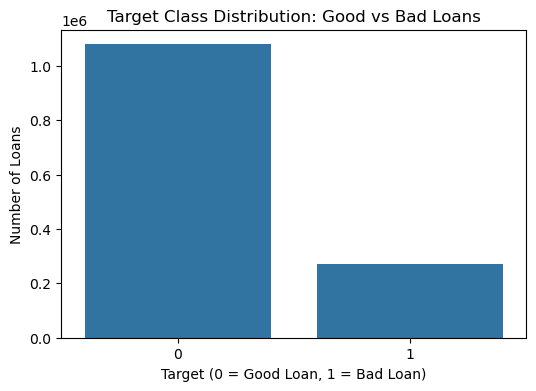

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="target")

plt.title("Target Class Distribution: Good vs Bad Loans")
plt.xlabel("Target (0 = Good Loan, 1 = Bad Loan)")
plt.ylabel("Number of Loans")

plt.show()

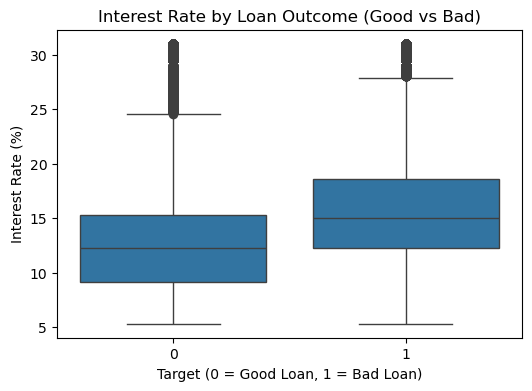

In [39]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="target", y="int_rate")
plt.title("Interest Rate by Loan Outcome (Good vs Bad)")
plt.xlabel("Target (0 = Good Loan, 1 = Bad Loan)")
plt.ylabel("Interest Rate (%)")
plt.show()

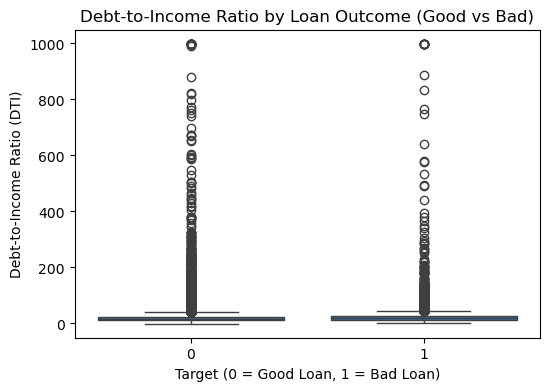

In [41]:
plt.figure(figsize=(6, 4))

sns.boxplot(data=df, x="target", y="dti")

plt.title("Debt-to-Income Ratio by Loan Outcome (Good vs Bad)")
plt.xlabel("Target (0 = Good Loan, 1 = Bad Loan)")
plt.ylabel("Debt-to-Income Ratio (DTI)")

plt.show()

In [43]:
df['dti'].describe()

count    1.347725e+06
mean     1.827425e+01
std      1.115549e+01
min     -1.000000e+00
25%      1.179000e+01
50%      1.761000e+01
75%      2.405000e+01
max      9.990000e+02
Name: dti, dtype: float64

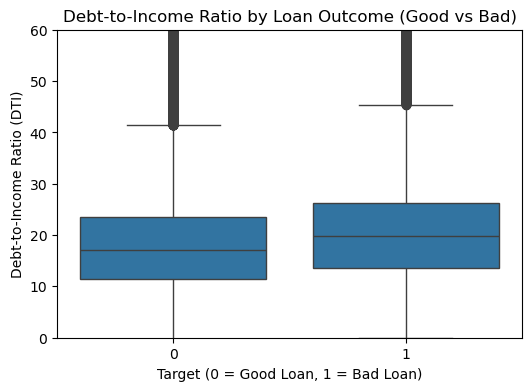

In [45]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="target", y="dti")
plt.ylim(0, 60)  # zoom into realistic DTI range
plt.title("Debt-to-Income Ratio by Loan Outcome (Good vs Bad)")
plt.xlabel("Target (0 = Good Loan, 1 = Bad Loan)")
plt.ylabel("Debt-to-Income Ratio (DTI)")
plt.show() 

In [47]:
#EDA Note: dti contains extreme outliers (max ~999%) and at least one invalid negative value (-1), 
#likely data entry errors or placeholder codes. Will cap/clean during feature engineering.

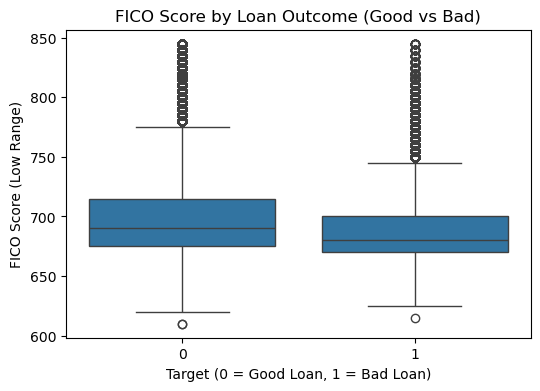

In [51]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="target", y="fico_range_low")
plt.title("FICO Score by Loan Outcome (Good vs Bad)")
plt.xlabel("Target (0 = Good Loan, 1 = Bad Loan)")
plt.ylabel("FICO Score (Low Range)")
plt.show()

In [53]:
grade_default_rate = df.groupby('grade')['target'].mean().sort_index()
grade_default_rate

grade
A    0.060435
B    0.133963
C    0.224431
D    0.303803
E    0.384311
F    0.451464
G    0.496676
Name: target, dtype: float64

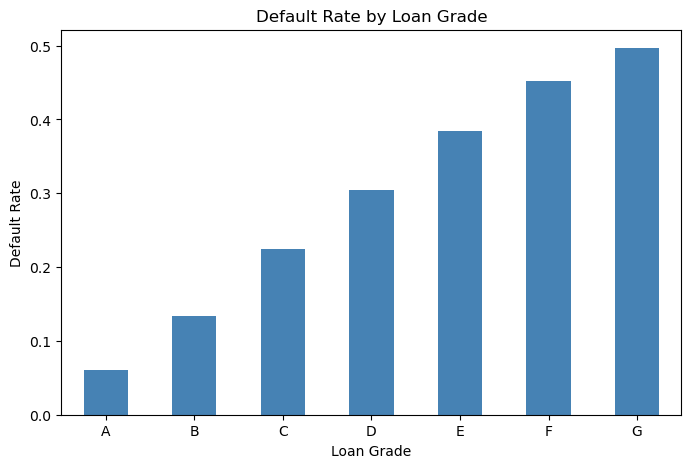

In [55]:
plt.figure(figsize=(8, 5))
grade_default_rate.plot(kind='bar', color='steelblue')
plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate")
plt.xticks(rotation=0)
plt.show()

EDA Note: Default rate increases monotonically from Grade A (6%) to Grade G (50%), confirming grade carries strong predictive signal. Since grade is LendingClub's own risk assessment, the model may partly learn to replicate their existing grading rather than fully independent patterns — worth noting in model interpretation later.

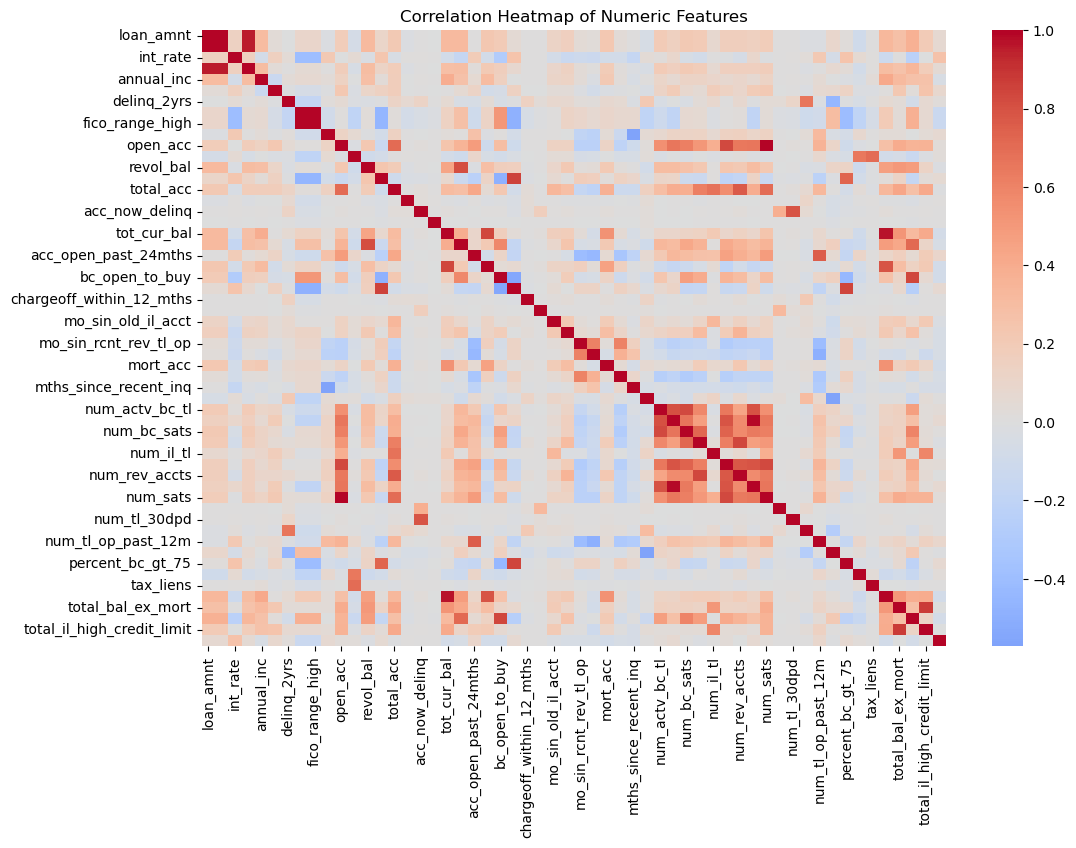

In [64]:
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [66]:
corr_matrix['loan_amnt'].sort_values(ascending=False)

loan_amnt                     1.000000
funded_amnt                   0.999545
installment                   0.953435
total_bc_limit                0.372893
tot_hi_cred_lim               0.335855
revol_bal                     0.316415
tot_cur_bal                   0.315584
total_rev_hi_lim              0.314728
annual_inc                    0.311851
total_bal_ex_mort             0.276394
avg_cur_bal                   0.230144
mort_acc                      0.224570
num_bc_sats                   0.215021
total_acc                     0.209264
total_il_high_credit_limit    0.200108
bc_open_to_buy                0.198754
num_bc_tl                     0.197737
num_actv_bc_tl                0.195906
open_acc                      0.186504
num_sats                      0.183225
num_rev_accts                 0.171097
num_op_rev_tl                 0.166958
mo_sin_old_rev_tl_op          0.164542
num_actv_rev_tl               0.152721
num_rev_tl_bal_gt_0           0.152140
int_rate                 

In [68]:
df[['fico_range_low', 'fico_range_high']].corr()

,fico_range_low,fico_range_high
fico_range_low,1.0,1.0
fico_range_high,1.0,1.0


In [70]:
redundant_cols = ['funded_amnt', 'fico_range_high']
df = df.drop(columns=redundant_cols)
df.shape

(1348099, 71)

In [74]:
df.to_csv('../data/processed/cleaned_loans.csv', index=False)

feature engineering

In [76]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/cleaned_loans.csv', low_memory=False)
df.shape

(1348099, 71)

In [78]:
missing = (df.isnull().mean() * 100)
missing[missing > 0].sort_values(ascending=False)

mths_since_recent_inq         13.116396
num_tl_120dpd_2m               8.912699
mo_sin_old_il_acct             8.035389
emp_title                      6.375645
emp_length                     5.826723
pct_tl_nvr_dlq                 5.224394
avg_cur_bal                    5.214602
num_rev_accts                  5.213044
mo_sin_old_rev_tl_op           5.213044
mo_sin_rcnt_rev_tl_op          5.213044
num_accts_ever_120_pd          5.212970
mo_sin_rcnt_tl                 5.212970
tot_hi_cred_lim                5.212970
num_tl_op_past_12m             5.212970
num_tl_90g_dpd_24m             5.212970
num_tl_30dpd                   5.212970
num_rev_tl_bal_gt_0            5.212970
num_op_rev_tl                  5.212970
num_il_tl                      5.212970
num_bc_tl                      5.212970
num_actv_rev_tl                5.212970
num_actv_bc_tl                 5.212970
total_il_high_credit_limit     5.212970
total_rev_hi_lim               5.212970
tot_coll_amt                   5.212970


In [81]:
df['emp_length'].value_counts(dropna=False)

emp_length
10+ years    442679
2 years      122100
< 1 year     108537
3 years      107868
1 year        88843
5 years       84326
4 years       80763
NaN           78550
6 years       62879
8 years       60811
7 years       59724
9 years       51019
Name: count, dtype: int64

In [83]:
df['emp_length'] = df['emp_length'].fillna('Unknown')

In [85]:
numeric_cols_to_impute = [
    'dti', 'revol_util', 'annual_inc', 'pub_rec_bankruptcies',
    'mths_since_recent_inq', 'mo_sin_old_il_acct', 'num_tl_120dpd_2m',
    'pct_tl_nvr_dlq', 'avg_cur_bal', 'num_rev_accts', 'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op', 'num_accts_ever_120_pd', 'mo_sin_rcnt_tl',
    'tot_hi_cred_lim', 'num_tl_op_past_12m', 'num_tl_90g_dpd_24m',
    'num_tl_30dpd', 'num_rev_tl_bal_gt_0', 'num_op_rev_tl', 'num_il_tl',
    'num_bc_tl', 'num_actv_rev_tl', 'num_actv_bc_tl',
    'total_il_high_credit_limit', 'total_rev_hi_lim', 'tot_coll_amt',
    'tot_cur_bal', 'bc_util', 'percent_bc_gt_75', 'bc_open_to_buy',
    'mths_since_recent_bc', 'num_bc_sats', 'num_sats', 'total_bc_limit',
    'total_bal_ex_mort', 'mort_acc', 'acc_open_past_24mths',
    'chargeoff_within_12_mths', 'collections_12_mths_ex_med', 'tax_liens',
    'inq_last_6mths', 'total_acc', 'delinq_amnt', 'pub_rec',
    'acc_now_delinq', 'delinq_2yrs', 'open_acc'
]

for col in numeric_cols_to_impute:
    df[col] = df[col].fillna(df[col].median())

In [87]:
cols_to_drop = ['emp_title', 'title', 'zip_code']
df = df.drop(columns=cols_to_drop)

In [89]:
missing = (df.isnull().mean() * 100)
missing[missing > 0].sort_values(ascending=False)

earliest_cr_line    0.002151
dtype: float64

In [91]:
df['issue_d'] = pd.to_datetime(df['issue_d'])
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])

/var/folders/1j/12p7zq9s2kvcm8cv6550skcc0000gn/T/ipykernel_1277/3329974766.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_d'] = pd.to_datetime(df['issue_d'])
/var/folders/1j/12p7zq9s2kvcm8cv6550skcc0000gn/T/ipykernel_1277/3329974766.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])


In [95]:
df['credit_history_months'] = (
    (df['issue_d'] - df['earliest_cr_line']).dt.days / 30.44
)

In [97]:
df['credit_history_months'].describe()

count    1.348070e+06
mean     1.949886e+02
std      9.008980e+01
min      6.044678e+00
25%      1.340342e+02
50%      1.769711e+02
75%      2.399803e+02
max      9.989159e+02
Name: credit_history_months, dtype: float64

In [99]:
df = df.drop(columns=['issue_d', 'earliest_cr_line'])
df.shape

(1348099, 67)

In [101]:
df.columns.tolist()

['loan_amnt',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'loan_status',
 'pymnt_plan',
 'purpose',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'fico_range_low',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'collections_12_mths_ex_med',
 'application_type',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'total_rev_hi_lim',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_since_recent_bc',
 'mths_since_recent_inq',
 'num_accts_ever_120_pd',
 'num_actv_bc_tl',
 'num_actv_rev_tl',
 'num_bc_sats',
 'num_bc_tl',
 'num_il_tl',
 'num_op_rev_tl',
 'num_rev_accts',
 'num_rev_tl_bal_gt_0',
 'num_sats',
 'num_tl_120dpd_2m',
 'num_tl_30dpd',
 'num_tl_90g_dpd_24m',
 'num_tl_op_past_12m'

In [103]:
df['pymnt_plan'].value_counts()

pymnt_plan
n    1348099
Name: count, dtype: int64

In [105]:
df['disbursement_method'].value_counts()

disbursement_method
Cash         1341199
DirectPay       6900
Name: count, dtype: int64

In [107]:
df = df.drop(
    columns=[
        "loan_status",
        "pymnt_plan",
        "disbursement_method",
        "addr_state",
        "grade"
    ]
)

In [111]:
df.shape

(1348099, 62)

In [113]:
df.select_dtypes(include='object').columns.tolist()

['term',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'verification_status',
 'purpose',
 'application_type']

encoding


In [116]:
# term
df['term'] = df['term'].map({'36 months': 36, '60 months': 60})

# sub_grade — A1=1 through G5=35
sub_grade_order = ['A1','A2','A3','A4','A5',
                   'B1','B2','B3','B4','B5',
                   'C1','C2','C3','C4','C5',
                   'D1','D2','D3','D4','D5',
                   'E1','E2','E3','E4','E5',
                   'F1','F2','F3','F4','F5',
                   'G1','G2','G3','G4','G5']
sub_grade_map = {g: i+1 for i, g in enumerate(sub_grade_order)}
df['sub_grade'] = df['sub_grade'].map(sub_grade_map)

# emp_length
emp_length_map = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10,
    'Unknown': -1
}
df['emp_length'] = df['emp_length'].map(emp_length_map)

# verification_status
df['verification_status'] = df['verification_status'].map({
    'Not Verified': 0,
    'Source Verified': 1,
    'Verified': 2
})

In [118]:
df = pd.get_dummies(df, columns=['home_ownership', 'purpose', 'application_type'], 
                    drop_first=True, dtype=int)

In [120]:
df.shape

(1348099, 78)

In [128]:
df.dtypes

loan_amnt                     float64
term                          float64
int_rate                      float64
installment                   float64
sub_grade                       int64
emp_length                      int64
annual_inc                    float64
verification_status             int64
dti                           float64
delinq_2yrs                   float64
fico_range_low                float64
inq_last_6mths                float64
open_acc                      float64
pub_rec                       float64
revol_bal                     float64
revol_util                    float64
total_acc                     float64
collections_12_mths_ex_med    float64
acc_now_delinq                float64
tot_coll_amt                  float64
tot_cur_bal                   float64
total_rev_hi_lim              float64
acc_open_past_24mths          float64
avg_cur_bal                   float64
bc_open_to_buy                float64
bc_util                       float64
chargeoff_wi

In [130]:
df.to_csv('../data/processed/featured_loans.csv', index=False)